In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"

np.set_printoptions(precision=3, suppress=True)
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import scale, StandardScaler

# Predict Nationality from Names
- In this exercise, we are going to get names of the European Parliment members from European Parliment website.
- We will use `xml.etree.ElementTree` library for turning an xml file in string format into xml file
- We will use `requests` library to request an`xml` file from a webpage

  - XML documents have sections, called elements, defined by a beginning and an ending tag. A tag is a markup construct that begins with < and ends with >. The characters between the start-tag and end-tag, if there are any, are the element's content. Elements can contain markup, including other elements, which are called "child elements".
  - The largest, top-level element is called the root, which contains all other elements.
  - Attributes are name–value pair that exist within a start-tag or empty-element tag. An XML attribute can only have a single value and each attribute can appear at most once on each element.
  

In [2]:
import xml.etree.ElementTree as ET

In [3]:
import requests

- `fromstring()` parses XML from a string directly into an `Element`, which is the root element of the parsed tree.

- We are now turning the xml string file into a list

Instead of XML can I just use a dataframe from cleaned CSV?

In [4]:
df = pd.read_csv('MEPS cleaned.csv')
df

,Member ID,Country,Full Name,Given Names,Surnames,EU Political Group,National Political Group,Multi-Part Given Name,Multi-Part Surname
0,256810,Finland,Mika AALTOLA,Mika,AALTOLA,Group of the European People's Party (Christia...,Kansallinen Kokoomus,0,0
1,257043,Spain,Maravillas ABADÍA JOVER,Maravillas,ABADÍA JOVER,Group of the European People's Party (Christia...,Partido Popular,0,1
2,197490,Poland,Magdalena ADAMOWICZ,Magdalena,ADAMOWICZ,Group of the European People's Party (Christia...,Independent,0,0
3,256820,Greece,Georgios AFTIAS,Georgios,AFTIAS,Group of the European People's Party (Christia...,Nea Demokratia,0,0
4,256987,Spain,Oihane AGIRREGOITIA MARTÍNEZ,Oihane,AGIRREGOITIA MARTÍNEZ,Renew Europe Group,Partido Nacionalista Vasco,0,1
...,...,...,...,...,...,...,...,...,...
714,28419,Italy,Nicola ZINGARETTI,Nicola,ZINGARETTI,Group of the Progressive Alliance of Socialist...,Partito Democratico,0,0
715,124884,Poland,Kosma ZŁOTOWSKI,Kosma,ZŁOTOWSKI,European Conservatives and Reformists Group,Prawo i Sprawiedliwość,0,0
716,197621,Spain,Juan Ignacio ZOIDO ÁLVAREZ,Juan Ignacio,ZOIDO ÁLVAREZ,Group of the European People's Party (Christia...,Partido Popular,1,1
717,185341,Croatia,Željana ZOVKO,Željana,ZOVKO,Group of the European People's Party (Christia...,Hrvatska demokratska zajednica,0,0


# EDA

- Create a bar graph showing the ratio of nationalities in the European parliament

Value Counts:
Country
Germany        96
France         81
Italy          76
Spain          60
Poland         53
Romania        33
Netherlands    31
Belgium        22
Greece         21
Sweden         21
Czechia        21
Hungary        21
Portugal       21
Austria        20
Bulgaria       17
Denmark        15
Slovakia       15
Finland        15
Ireland        14
Croatia        12
Lithuania      11
Slovenia        9
Latvia          9
Estonia         7
Luxembourg      6
Cyprus          6
Malta           6
Name: count, dtype: int64


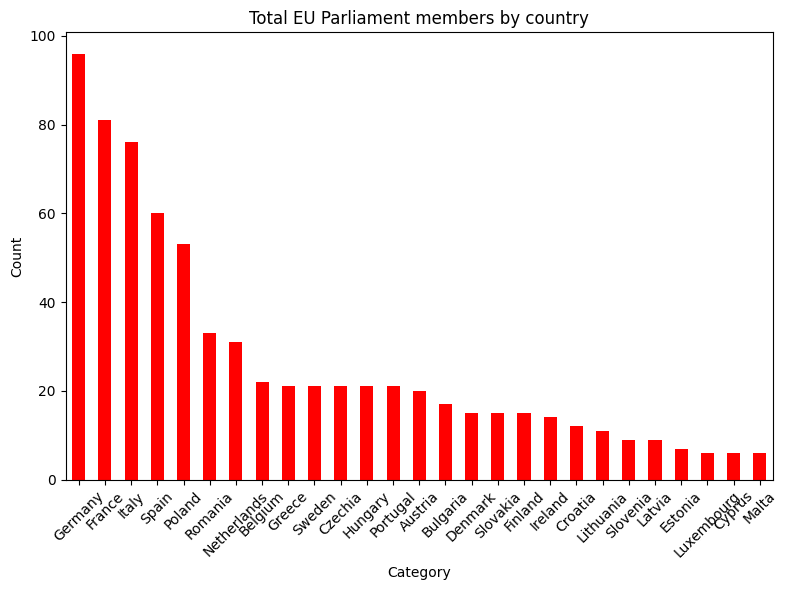

In [5]:
# Calculate value counts
counts = df['Country'].value_counts()
print("Value Counts:")
print(counts)

# Create bar chart
plt.figure(figsize=(8, 6)) # Optional: adjust figure size
counts.plot(kind='bar', color='red')
plt.title('Total EU Parliament members by country')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45) # Keeps x-axis labels horizontal
plt.tight_layout() # Adjust layout to make room for labels
plt.show()

- print the value counts of the members per country

In [6]:
counts

Country
Germany        96
France         81
Italy          76
Spain          60
Poland         53
Romania        33
Netherlands    31
Belgium        22
Greece         21
Sweden         21
Czechia        21
Hungary        21
Portugal       21
Austria        20
Bulgaria       17
Denmark        15
Slovakia       15
Finland        15
Ireland        14
Croatia        12
Lithuania      11
Slovenia        9
Latvia          9
Estonia         7
Luxembourg      6
Cyprus          6
Malta           6
Name: count, dtype: int64

- Get the names of the first 8 countries with the largest number of meps

In [7]:
# Create new dataframe with only the top 8 largest countries by total members
top_21 = df['Country'].value_counts().nlargest(21).index
top_21_df = df[df['Country'].isin(top_21)].copy()

In [8]:
top_21_df

,Member ID,Country,Full Name,Given Names,Surnames,EU Political Group,National Political Group,Multi-Part Given Name,Multi-Part Surname
0,256810,Finland,Mika AALTOLA,Mika,AALTOLA,Group of the European People's Party (Christia...,Kansallinen Kokoomus,0,0
1,257043,Spain,Maravillas ABADÍA JOVER,Maravillas,ABADÍA JOVER,Group of the European People's Party (Christia...,Partido Popular,0,1
2,197490,Poland,Magdalena ADAMOWICZ,Magdalena,ADAMOWICZ,Group of the European People's Party (Christia...,Independent,0,0
3,256820,Greece,Georgios AFTIAS,Georgios,AFTIAS,Group of the European People's Party (Christia...,Nea Demokratia,0,0
4,256987,Spain,Oihane AGIRREGOITIA MARTÍNEZ,Oihane,AGIRREGOITIA MARTÍNEZ,Renew Europe Group,Partido Nacionalista Vasco,0,1
...,...,...,...,...,...,...,...,...,...
712,103246,Netherlands,Auke ZIJLSTRA,Auke,ZIJLSTRA,Patriots for Europe Group,Partij voor de Vrijheid,0,0
714,28419,Italy,Nicola ZINGARETTI,Nicola,ZINGARETTI,Group of the Progressive Alliance of Socialist...,Partito Democratico,0,0
715,124884,Poland,Kosma ZŁOTOWSKI,Kosma,ZŁOTOWSKI,European Conservatives and Reformists Group,Prawo i Sprawiedliwość,0,0
716,197621,Spain,Juan Ignacio ZOIDO ÁLVAREZ,Juan Ignacio,ZOIDO ÁLVAREZ,Group of the European People's Party (Christia...,Partido Popular,1,1


In [9]:
top_21_df.columns

Index(['Member ID', 'Country', 'Full Name', 'Given Names', 'Surnames',
       'EU Political Group', 'National Political Group',
       'Multi-Part Given Name', 'Multi-Part Surname'],
      dtype='object')

# Predictions

- create a data with the parliament members in the first eight countries
- split data into test and train datasets

In [10]:
X = top_21_df["Full Name"]
y = top_21_df["Country"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

- create a pipeline of `countvectorizer` and `logisticregressioncv`
- report the cross validation scores

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegressionCV

pipeline = Pipeline([
    ("vectorizer", CountVectorizer(
        analyzer="char",
        ngram_range=(2, 4),   # bigrams to 4-grams
        lowercase=True
    )),
    ("classifier", LogisticRegressionCV(
        cv=5,
        max_iter=5000,
        n_jobs=-1,
        multi_class="multinomial"
    ))
])


In [12]:
pipeline.fit(X_train, y_train)

/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1905: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('vectorizer',
                 CountVectorizer(analyzer='char', ngram_range=(2, 4))),
                ('classifier',
                 LogisticRegressionCV(cv=5, max_iter=5000,
                                      multi_class='multinomial', n_jobs=-1))])

In [13]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5
)

print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1905: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1905: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1905: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1905: FutureWar

Cross-validation scores: [0.435 0.407 0.407 0.398 0.435]
Mean CV score: 0.4166666666666667


In [14]:
test_accuracy = pipeline.score(X_test, y_test)
print("Test accuracy:", test_accuracy)

Test accuracy: 0.5294117647058824


- Repeat the same procedure, with vectorizer having the parameter of analyzer="char_wb"

 - analyzer{‘word’, ‘char’, ‘char_wb’} or callable, default=’word’ Whether the feature should be made of word n-gram or character n-grams. Option ‘char_wb’ creates character n-grams only from text inside word boundaries; n-grams at the edges of words are padded with space.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegressionCV

pipe_char_wb = Pipeline([
    ("vectorizer", CountVectorizer(
        analyzer="char_wb",
        ngram_range=(2, 4),
        lowercase=True
    )),
    ("classifier", LogisticRegressionCV(
        cv=5,
        max_iter=5000,
        n_jobs=-1,
        multi_class="multinomial"
    ))
])

pipe_char_wb.fit(X_train, y_train)


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1905: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('vectorizer',
                 CountVectorizer(analyzer='char_wb', ngram_range=(2, 4))),
                ('classifier',
                 LogisticRegressionCV(cv=5, max_iter=5000,
                                      multi_class='multinomial', n_jobs=-1))])

In [16]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores_char_wb = cross_val_score(
    pipe_char_wb,
    X_train,
    y_train,
    cv=5
)

print("char_wb CV scores:", cv_scores_char_wb)
print("char_wb mean CV:", cv_scores_char_wb.mean())
print("char_wb std CV:", cv_scores_char_wb.std())


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1905: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1905: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1905: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1905: FutureWar

char_wb CV scores: [0.454 0.435 0.454 0.444 0.444]
char_wb mean CV: 0.4462962962962963
char_wb std CV: 0.006928995160692497


In [17]:
test_acc_char_wb = pipe_char_wb.score(X_test, y_test)
print("char_wb test accuracy:", test_acc_char_wb)


char_wb test accuracy: 0.5220588235294118


- print the top 20 most important and least important n-grams

In [18]:
pipe_char_wb.fit(X_train, y_train)

/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1905: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('vectorizer',
                 CountVectorizer(analyzer='char_wb', ngram_range=(2, 4))),
                ('classifier',
                 LogisticRegressionCV(cv=5, max_iter=5000,
                                      multi_class='multinomial', n_jobs=-1))])

In [19]:
import numpy as np
import pandas as pd

# Get vectorizer and classifier
vectorizer = pipe_char_wb.named_steps["vectorizer"]
classifier = pipe_char_wb.named_steps["classifier"]

# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Get coefficient matrix
coefs = classifier.coef_


In [20]:
import matplotlib.pyplot as plt
import numpy as np

vectorizer = pipe_char_wb.named_steps["vectorizer"]
classifier = pipe_char_wb.named_steps["classifier"]

feature_names = vectorizer.get_feature_names_out()
coefs = classifier.coef_
countries = classifier.classes_


In [21]:
def plot_important_features(coef, feature_names, top_n=20, ax=None, rotation=60):
    if ax is None:
        ax = plt.gca()
    inds = np.argsort(coef)
    low = inds[:top_n]
    high = inds[-top_n:]
    important = np.hstack([low, high])
    myrange = range(len(important))
    colors = ['red'] * top_n + ['blue'] * top_n
    
    ax.bar(myrange, coef[important], color=colors)
    ax.set_xticks(myrange)
    ax.set_xticklabels(feature_names[important], rotation=rotation, ha="right")
    ax.set_xlim(-.7, 2 * top_n)
    ax.set_frame_on(False)

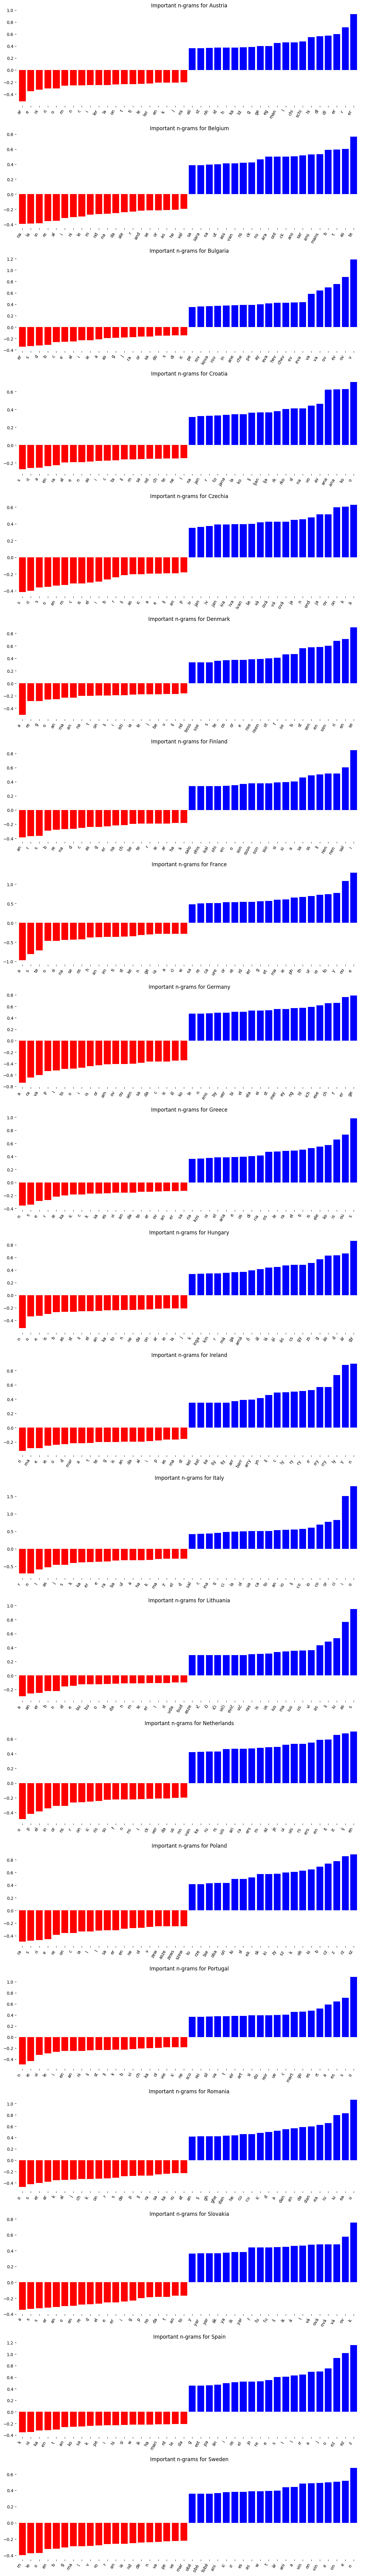

In [22]:
fig, axes = plt.subplots(len(countries), 1, figsize=(12, 4 * len(countries)))

for i, country in enumerate(countries):
    plot_important_features(
        coefs[i],
        feature_names,
        top_n=20,
        ax=axes[i]
    )
    axes[i].set_title(f"Important n-grams for {country}")

plt.tight_layout()
plt.show()


- Now make a gridsearch over logistic regression, countvectorizer n-grams, min_df and normalizer

In [23]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import Normalizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split

# X/y
X = top_21_df["Full Name"]
y = top_21_df["Country"]

# train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("vect", CountVectorizer(analyzer="char_wb", lowercase=True)),
    ("norm", "passthrough"),  # toggled by GridSearch
    ("clf", LogisticRegression(
        max_iter=5000,
        multi_class="multinomial",
        solver="saga"   # supports multinomial and scales well
    ))
])


In [24]:
param_grid = {
    "vect__ngram_range": [(2, 3), (2, 4), (3, 5)],
    "vect__min_df": [1, 2, 5],

    # normalizer off vs on (L2 and L1 are common)
    "norm": ["passthrough", Normalizer(norm="l2"), Normalizer(norm="l1")],

    # logistic regression strength
    "clf__C": [0.1, 1.0, 3.0, 10.0],
}


In [ ]:
grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best CV accuracy:", grid.best_score_)
print("Best params:", grid.best_params_)

print("Test accuracy (best estimator):", grid.score(X_test, y_test))


Fitting 5 folds for each of 108 candidates, totalling 540 fits


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWar

In [40]:
import pandas as pd

results = pd.DataFrame(grid.cv_results_)
cols = [
    "mean_test_score", "std_test_score",
    "param_vect__ngram_range", "param_vect__min_df",
    "param_norm", "param_clf__C",
]
print(results[cols].sort_values("mean_test_score", ascending=False).head(10))


    mean_test_score  std_test_score param_vect__ngram_range  \
91         0.601104        0.049210                  (2, 4)   
64         0.590068        0.065780                  (2, 4)   
1          0.590030        0.064252                  (2, 4)   
94         0.589992        0.049614                  (2, 4)   
67         0.589992        0.062052                  (2, 4)   
28         0.587291        0.045612                  (2, 4)   
4          0.587291        0.062708                  (2, 4)   
0          0.581697        0.059284                  (2, 3)   
82         0.578957        0.036660                  (2, 4)   
55         0.578957        0.044286                  (2, 4)   

    param_vect__min_df    param_norm  param_clf__C  
91                   1  Normalizer()          10.0  
64                   1  Normalizer()           3.0  
1                    1   passthrough           0.1  
94                   2  Normalizer()          10.0  
67                   2  Normalizer()     

- adding this myself: datafrme

In [47]:
import pandas as pd
import numpy as np

# Predict labels
y_pred = grid.predict(X_test)

# Predict probabilities
y_proba = grid.predict_proba(X_test)

# Maximum probability (model confidence)
confidence = np.max(y_proba, axis=1)

results_df = pd.DataFrame({
    "Full Name": X_test.values,
    "True Country": y_test.values,
    "Predicted Country": y_pred,
    "Confidence": confidence
})

results_df['Correct'] = (results_df['True Country'] == results_df['Predicted Country']).astype(int)
results_df

,Full Name,True Country,Predicted Country,Confidence,Correct
0,Paolo BORCHIA,Italy,Italy,0.696147,1
1,Fabienne KELLER,France,Germany,0.762462,0
2,Damian BOESELAGER,Germany,Germany,0.530577,1
3,Gabriel MATO,Spain,Germany,0.292223,0
4,Leoluca ORLANDO,Italy,Italy,0.480618,1
...,...,...,...,...,...
86,Gilles PENNELLE,France,France,0.624933,1
87,Nicola ZINGARETTI,Italy,Italy,0.703542,1
88,Jeroen LENAERS,Netherlands,Germany,0.680178,0
89,Roberto VANNACCI,Italy,Italy,0.797326,1


In [46]:
proba_df = pd.DataFrame(
    y_proba,
    columns=grid.classes_
)

results_df = pd.concat([
    pd.DataFrame({
        "Full Name": X_test.values,
        "True Country": y_test.values,
        "Predicted Country": y_pred
    }).reset_index(drop=True),
    proba_df.reset_index(drop=True)
], axis=1)

results_df.head()


,Full Name,True Country,Predicted Country,Belgium,France,Germany,Italy,Netherlands,Poland,Romania,Spain
0,Paolo BORCHIA,Italy,Italy,0.040934,0.029708,0.043453,0.696147,0.016074,0.040522,0.019150,0.114011
1,Fabienne KELLER,France,Germany,0.032201,0.122368,0.762462,0.013954,0.014632,0.027252,0.007989,0.019142
2,Damian BOESELAGER,Germany,Germany,0.047045,0.034433,0.530577,0.054255,0.091482,0.066950,0.143297,0.031960
3,Gabriel MATO,Spain,Germany,0.077215,0.150386,0.292223,0.208148,0.072675,0.083834,0.033469,0.082049
4,Leoluca ORLANDO,Italy,Italy,0.017556,0.152638,0.043019,0.480618,0.024653,0.058352,0.058267,0.164897


In [ ]:
new

In [55]:
# Get predictions and probabilities
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)
confidence = np.max(y_proba, axis=1)

# Basic results dataframe
results_df = pd.DataFrame({
    "Full Name": X_test.values,
    "True Country": y_test.values,
    "Predicted Country": y_pred,
    "Confidence": confidence
})

# Add correctness column
results_df["Correct"] = (
    results_df["True Country"] == results_df["Predicted Country"]
).astype(int)

# Reorder columns for neatness
results_df = results_df[
    ["Full Name", "Correct", "True Country", "Predicted Country", "Confidence"]
]

# Create probability columns for each country
prob_columns = [f"prob_{country}" for country in grid.classes_]

proba_df = pd.DataFrame(
    y_proba,
    columns=prob_columns
)

# Merge
results_df = pd.concat(
    [results_df.reset_index(drop=True),
     proba_df.reset_index(drop=True)],
    axis=1
)

# Display
results_df

,Full Name,Correct,True Country,Predicted Country,Confidence,prob_Belgium,prob_France,prob_Germany,prob_Italy,prob_Netherlands,prob_Poland,prob_Romania,prob_Spain
0,Paolo BORCHIA,1,Italy,Italy,0.696147,0.040934,0.029708,0.043453,0.696147,0.016074,0.040522,0.019150,0.114011
1,Fabienne KELLER,0,France,Germany,0.762462,0.032201,0.122368,0.762462,0.013954,0.014632,0.027252,0.007989,0.019142
2,Damian BOESELAGER,1,Germany,Germany,0.530577,0.047045,0.034433,0.530577,0.054255,0.091482,0.066950,0.143297,0.031960
3,Gabriel MATO,0,Spain,Germany,0.292223,0.077215,0.150386,0.292223,0.208148,0.072675,0.083834,0.033469,0.082049
4,Leoluca ORLANDO,1,Italy,Italy,0.480618,0.017556,0.152638,0.043019,0.480618,0.024653,0.058352,0.058267,0.164897
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,Gilles PENNELLE,1,France,France,0.624933,0.025904,0.624933,0.096783,0.129159,0.019218,0.017979,0.013854,0.072172
87,Nicola ZINGARETTI,1,Italy,Italy,0.703542,0.011279,0.102118,0.063704,0.703542,0.017659,0.019955,0.054280,0.027462
88,Jeroen LENAERS,0,Netherlands,Germany,0.680178,0.015291,0.033744,0.680178,0.008751,0.122592,0.014627,0.008538,0.116278
89,Roberto VANNACCI,1,Italy,Italy,0.797326,0.049783,0.024173,0.027653,0.797326,0.027567,0.032878,0.014310,0.026309


In [56]:
import pandas as pd

by_country_df = (
    results_df
    .groupby("True Country")
    .agg(
        n=("True Country", "size"),
        correct=("Correct", "sum"),
        accuracy=("Correct", "mean"),
        avg_confidence=("Confidence", "mean"),
        median_confidence=("Confidence", "median"),
    )
    .sort_values(["accuracy", "n"], ascending=[False, False])
    .reset_index()
)

by_country_df


,True Country,n,correct,accuracy,avg_confidence,median_confidence
0,Italy,15,14,0.933333,0.571090,0.593251
1,France,16,14,0.875000,0.562972,0.544264
2,Spain,12,10,0.833333,0.544368,0.540235
3,Poland,11,9,0.818182,0.629531,0.581840
4,Germany,19,12,0.631579,0.550396,0.469094
5,Romania,7,4,0.571429,0.442472,0.391810
6,Netherlands,6,0,0.000000,0.524377,0.570203
7,Belgium,5,0,0.000000,0.335097,0.335955


Maybe not surprising that Belgium is so hard - mix of Dutch and French names.

In [57]:
# Count confusions (only incorrect rows)
confusions = (
    results_df[results_df["Correct"] == 0]
    .groupby(["True Country", "Predicted Country"])
    .size()
    .reset_index(name="count")
)

# For each true country, keep the predicted country with max count
top_confusion = (
    confusions.sort_values(["True Country", "count"], ascending=[True, False])
    .drop_duplicates("True Country")
    .rename(columns={
        "Predicted Country": "most_common_wrong_pred",
        "count": "most_common_wrong_count"
    })
)

by_country_df = by_country_df.merge(top_confusion, on="True Country", how="left")
by_country_df


,True Country,n,correct,accuracy,avg_confidence,median_confidence,most_common_wrong_pred,most_common_wrong_count
0,Italy,15,14,0.933333,0.571090,0.593251,Germany,1
1,France,16,14,0.875000,0.562972,0.544264,Germany,1
2,Spain,12,10,0.833333,0.544368,0.540235,France,1
3,Poland,11,9,0.818182,0.629531,0.581840,Germany,1
4,Germany,19,12,0.631579,0.550396,0.469094,France,3
5,Romania,7,4,0.571429,0.442472,0.391810,Spain,2
6,Netherlands,6,0,0.000000,0.524377,0.570203,Germany,3
7,Belgium,5,0,0.000000,0.335097,0.335955,France,3


Romania is frequently mistaken for Spain, and Spain for France. Makes sense since they are all in the same language group.

Still, it is difficult to draw larger conclusions from such a small dataset. If I am only working with names and countries, maybe it would be beneficial to find additional names from each country.